# MIL-CREDA frente a CREDA — el informe (v1)

Este cuaderno no corre nada. Lee lo que dejó `Benchmark_Campaign_v1.ipynb` bajo `MIL-CREDA/Results/Benchmark/` — `summary.json`, `runs.jsonl` y el registro de la búsqueda del techo — y arma las tablas, las figuras y el informe a partir de esos archivos. Corregir una frase del informe cuesta volver a correr esta celda en adelante, segundos, y no la campaña entera.
Diez métodos sobre seis transferencias. Cada peldaño se diferencia del anterior en
**una sola cosa**, así una diferencia se puede atribuir a esa cosa y a ninguna otra.

El nombre dice qué le falta al método: un asterisco marca un componente ausente,
dos marcan dos, y un nombre sin marca es el método completo.

| id | nombre | adaptación | ponderación | término local | instancias que usa |
|---|---|---|---|---|---|
| `A` | `Baseline` | — | — | — | todas |
| `C` | `CREDA*` | CREDA | — | — | todas |
| `D` | `CREDA` | CREDA | sí | — | todas |
| `B` | `MIL-Baseline` | — | — | — | todas |
| `E` | `MIL-CREDA**` | MIL-CREDA | — | — | todas |
| `F` | `MIL-CREDA*` | MIL-CREDA | sí | — | todas |
| `G` | `MIL-CREDA` | MIL-CREDA | sí | sí | todas |
| `SU` | `MIL-CREDA-U` | MIL-CREDA | sí | sí | 10, selección regular |
| `SA` | `MIL-CREDA-A` | MIL-CREDA | sí | sí | 10, selección arbitraria |
| `SK` | `MIL-CREDA-K` | MIL-CREDA | sí | sí | 10, las de mayor atención |

Los últimos tres mantienen fijo el presupuesto de instancias y se diferencian solo
en la regla que lo gasta, así que `MIL-CREDA-U → MIL-CREDA-K` y
`MIL-CREDA-A → MIL-CREDA-K` son atribuibles a la regla. `MIL-CREDA-K → MIL-CREDA`
es la pregunta aparte de cuánto cuesta el presupuesto en sí.

Todo lo de abajo está acotado por `config.py`, y solo dos constantes separan esta
corrida de la completa. **Leer el encabezado de cada tabla antes que sus números**:
por debajo del piso de repeticiones declarado no se otorga ningún veredicto y el
motivo queda estampado.

> **De dónde sale el registro que lee este cuaderno.**
>
> `summary.json` y `runs.jsonl` los escribió `tools/bridge.py` mezclando los diez
> shards que volvieron de los envíos remotos — 30 semillas, 20 épocas, las diez en
> la misma tarjeta. No los escribió `Benchmark_Campaign_v1.ipynb`, que no se
> re-ejecuta y cuyas salidas son de una corrida local anterior. La provenance del
> registro está en `Results/Benchmark/PROVENANCE.txt` y se muestra más abajo.


In [1]:
#!/usr/bin/env python3
"""The first code cell of every notebook a job may run — copied byte for byte.

One question, answered once: WHERE IS THE REPOSITORY THIS NOTEBOOK RUNS
AGAINST. Every later cell reads `ROOT` and none of them asks again.

Opened by a person on their own machine, this answers it exactly the way
these notebooks always have. A notebook lives at `<repo>/<Name>/Notebooks/`,
so the repository is two directories above the working directory. Nothing was
handed over, nothing is checked, and the behaviour is unchanged.

Started by a runner on a remote worker, it does not answer it by looking
around. The runner exports the directory it cloned the pinned commit into and
the commit it pinned; this cell reads both, and PROVES the checkout is at that
commit before returning it.

Guessing is the whole reason this cell exists. Under the runner the kernel's
working directory is the runner's own and the clone sits one level inside it,
so two directories up is two levels ABOVE the working directory — a directory
that EXISTS on any worker. The path resolves, the insert succeeds, and the run
dies later with a missing module naming a package, never with the wrong root.
The one fact worth having is the one the failure never mentions.

Three refusals, and each one is a refusal rather than a fallback because this
is the path that spends metered quota:

- **Half a handoff** — one variable present and the other missing. Something
  built this environment and got it half right; that is precisely the state a
  fallback cannot tell apart from a laptop, and the fallback resolves a
  directory that exists everywhere.
- **A root that is not a checkout** — the declared directory is missing, or
  holds no readable `HEAD`. There is nothing to compare against, and an
  unproven root is what this cell was written to stop being acceptable.
- **A checkout at a different commit** — the declared commit and the one on
  disk disagree. A job that runs the wrong commit RUNS: it returns numbers
  shaped exactly like the right ones, and nothing downstream can tell.

Absent means LOCAL. It never means "work it out".

Importable and independently testable, the way the runner's own two cells
are: every function is pure and takes its environment and its working
directory as arguments, and only the last line — the binding a notebook cell
exists to perform — reads the real ones.
"""
import os
from pathlib import Path

#: The directory a runner cloned the pinned commit into. Forge-owned and
#: deliberately generic: this is the contract between a runner and the
#: notebook it starts, not a name borrowed from any one repository.
CLONE_ROOT_ENV = "FORGE_CLONE_ROOT"

#: The commit that clone was pinned to, exported beside it so this cell can
#: check rather than trust. A root on its own would only move the guess one
#: step: a directory handed over is still a directory nobody proved.
CLONE_COMMIT_ENV = "FORGE_CLONE_COMMIT"

#: How far above a notebook's own directory the repository sits when nobody
#: hands anything over: `<repo>/<Name>/Notebooks` -> `<repo>`.
LOCAL_ROOT_DEPTH = 1


def head_commit(root):
    """The commit `root`'s `HEAD` names, read straight out of `.git`.

    No subprocess, deliberately. A notebook cell that shells out needs a git
    binary on a worker's PATH that nothing here declared, and every checker
    that reads these notebooks then has to decide whether running the cell is
    safe — a cell that binds the repository is the last one that may be
    skipped for that reason.

    A pinned checkout is detached: the runner fetches a commit and checks out
    what it fetched, never a branch, so `HEAD` holds the raw commit and this
    is a one-line read. A symbolic `HEAD` is resolved anyway — through the
    loose ref and then `packed-refs` — so pointing these variables at an
    ordinary checkout gets an answer instead of a refusal that would be about
    the file format rather than about the commit.

    Returns `None` when there is nothing to read. The caller turns that into
    a refusal; this function never decides.
    """
    git = Path(root) / ".git"
    if git.is_file():
        pointer = git.read_text(encoding="utf-8").strip()
        if not pointer.startswith("gitdir:"):
            return None
        git = Path(root) / pointer[len("gitdir:"):].strip()
    if not git.is_dir():
        return None
    head = git / "HEAD"
    if not head.is_file():
        return None
    text = head.read_text(encoding="utf-8").strip()
    if not text.startswith("ref:"):
        return text or None
    ref = text[len("ref:"):].strip()
    loose = git / ref
    if loose.is_file():
        return loose.read_text(encoding="utf-8").strip() or None
    packed = git / "packed-refs"
    if packed.is_file():
        for line in packed.read_text(encoding="utf-8").splitlines():
            if line.startswith("#") or line.startswith("^"):
                continue
            fields = line.split()
            if len(fields) == 2 and fields[1] == ref:
                return fields[0]
    return None


def resolve_repository_root(environ=None, cwd=None, head_reader=head_commit):
    """The repository this notebook runs against, or a refusal saying why.

    `environ` and `cwd` are arguments so the whole decision can be driven
    without a kernel, a clone or a worker; the binding at the bottom of this
    cell passes the real ones.
    """
    environ = os.environ if environ is None else environ
    here = Path.cwd() if cwd is None else Path(cwd)
    declared_root = environ.get(CLONE_ROOT_ENV)
    declared_commit = environ.get(CLONE_COMMIT_ENV)

    if not declared_root and not declared_commit:
        return here.parents[LOCAL_ROOT_DEPTH]

    if not declared_root or not declared_commit:
        raise RuntimeError(
            "half a handoff: {0}={1!r} and {2}={3!r}. Both name the pinned "
            "checkout this notebook must run against, and one without the "
            "other is an environment somebody built and got half right. "
            "Falling back to the local layout here would resolve a directory "
            "that exists on any machine and is not this repository.".format(
                CLONE_ROOT_ENV, declared_root,
                CLONE_COMMIT_ENV, declared_commit))

    root = Path(declared_root)
    found = head_reader(root) if root.is_dir() else None
    if found is None:
        raise RuntimeError(
            "{0}={1!r} is not a readable checkout: no commit could be read "
            "from its HEAD. {2} declares {3!r}, and there is nothing here to "
            "check it against.".format(
                CLONE_ROOT_ENV, declared_root,
                CLONE_COMMIT_ENV, declared_commit))
    if found.lower() != declared_commit.lower():
        raise RuntimeError(
            "the checkout at {0}={1!r} is at commit {2}, and {3} declares "
            "{4}. A job that runs a commit nobody asked for RUNS, and the "
            "numbers it returns look exactly like the right ones.".format(
                CLONE_ROOT_ENV, declared_root, found,
                CLONE_COMMIT_ENV, declared_commit))
    return root


ROOT = resolve_repository_root()


In [2]:
# The repository was resolved by the cell above -- the forge's own, travelling
# byte for byte -- and this one only uses it. `REPOSITORY` is still the name
# every cell below reads, so nothing below changes.
import os
import sys
from pathlib import Path

REPOSITORY = ROOT
sys.path.insert(0, str(REPOSITORY / "src"))
print("repository:", REPOSITORY)

# Read AND write: this notebook writes into config.RESULTS too (the
# curve PDFs below, report.txt/report.md, the runs it exports), so a
# read-only override would render a scratch merge and then write its
# report into the canonical Results directory -- exactly the copy
# tools/bridge.py's own provenance note forbids. Same rule as the two
# variables the cell above reads: unset means "behave exactly as before".
MIL_CREDA_RESULTS_OVERRIDE = os.environ.get("MIL_CREDA_RESULTS")

repository: /Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation


In [3]:
import json
from pathlib import Path

from IPython.display import Markdown, display

from MIL_CREDA_Benchmark import config, harness, tables

# The scratch-merge override, resolved once, covering reads AND writes
# below -- see the bootstrap cell for why both directions matter.
RESULTS = (Path(MIL_CREDA_RESULTS_OVERRIDE) if MIL_CREDA_RESULTS_OVERRIDE
           else config.results_for(0.0, "campaign", False))
if MIL_CREDA_RESULTS_OVERRIDE:
    print(f"MIL_CREDA_RESULTS override active: {RESULTS}")


def show(text: str) -> None:
    """Una tabla se muestra como tabla, no como texto de ancho fijo.

    Es la misma cadena que va al registro, renderizada. Nada se vuelve a
    calcular acá: si esto y el archivo dijeran cosas distintas, habría dos
    versiones del mismo número y ninguna forma de saber cuál se movió.
    """
    display(Markdown(text))


# Los mismos registros que dejó la corrida, nunca recalculados: si esta
# celda y el archivo dijeran cosas distintas, habría dos versiones del mismo
# número y ninguna forma de saber cuál se movió.
# La corrida completa primero, y el ensayo sólo si no hay ninguna. La completa
# gana siempre que exista: que un ensayo le ganara haría que este informe
# cambiara de fuente sin que nadie lo tocara, y hacia abajo. `source_note` dice
# de cuál de las dos salieron los números --- siempre, no sólo cuando es un
# ensayo, porque un aviso que aparece únicamente en el caso malo no le enseña a
# nadie qué es lo que vigila.
from MIL_CREDA_Benchmark import contamination as _eje

_vigente = _eje.in_force(0.0, "campaign")
if _vigente is None:
    raise SystemExit(
        "no hay registro para ρ=0: ni corrida completa ni ensayo. Corré la "
        "campaña (`campaign-local` deja el ensayo en Results/Pilot).")
if MIL_CREDA_RESULTS_OVERRIDE:
    runs = [json.loads(line) for line in
            (RESULTS / "runs.jsonl").read_text().splitlines() if line.strip()]
    summary = json.loads((RESULTS / "summary.json").read_text())
else:
    runs, summary = _vigente["runs"], _vigente["summary"]
    RESULTS = _vigente["root"]
ES_ENSAYO = bool(_vigente["pilot"]) and not MIL_CREDA_RESULTS_OVERRIDE
PROCEDENCIA = _eje.source_note(_vigente, 0.0)
reduction = harness.Reduction(**summary["reduction"])
# Con la escala de la corrida que este informe dibuja, y antes sin ninguna. El
# argumento escrito acá era que «los techos son un registro aparte que un ensayo
# puede consumir completo sin haber gastado Kaggle», y describía lo que pasaba:
# `config.ceilings_on_record()` no tenía cómo recibir una escala, así que una
# campaña de ensayo corría bajo la búsqueda COMPLETA y el informe tenía que leer
# ese mismo archivo para no contradecirla.
#
# Ahora la recibe, y la corrida de ensayo corre bajo `ceilings.pilot.json`. Una
# llamada pelada acá mostraría la rejilla de la búsqueda completa ---20 épocas,
# 30 trials--- encabezando las tablas de una campaña que no corrió bajo ninguno
# de esos números: el informe diría la verdad sobre el archivo equivocado, que
# es exactamente la falla que la coordenada existe para cerrar. La escala es un
# modo del recorrido entero, y este cuaderno está adentro de él.
registro_busqueda = harness.search_record(pilot=ES_ENSAYO)
# De cuál de los dos salieron, dicho siempre y no sólo cuando es un ensayo:
# el mismo mecanismo que `PROCEDENCIA` para la campaña, no un segundo aviso.
PROCEDENCIA_TECHOS = harness.search_source_note(pilot=ES_ENSAYO)

# Las transferencias salen del registro y no de `config`: la tabla de techos
# describe la corrida que se hizo, no la configuración que hay ahora. Una
# transferencia agregada después dejaría una columna sin datos que igual se
# leería como parte de esta corrida.
TRANSFERENCIAS = list(summary["grid"])

if summary.get("provenance"):
    print(summary["provenance"])
print(f"{len(runs)} corridas · {len(summary['grid'])} transferencias")
# El nivel contaminado que este informe muestra al lado de cada tabla
# limpia. Fijado antes de correr nada --- el punto medio del rango ---
# así que ningún resultado pudo haberlo elegido.
RHO = config.NOISE_REPORTED

# Las tres transferencias que llevan las figuras. Cuántas es de la figura --- seis
# paneles legibles no entran en una página y las tablas ya llevan las seis, y el
# tope está en `FIGURE_TRANSFER_COUNT`. Cuáles es de esta regla: donde los métodos
# llegan más alto, elegido por el resultado y por eso declarado en el epígrafe.
#
# Se calcula UNA vez, sobre el registro limpio, y la misma lista va a la figura
# limpia y a la contaminada. Elegirlas por registro daría dos figuras que se
# comparan lado a lado y difieren en dos cosas.
FIGURAS = tables.best_transfers(runs)

/Users/diego/Proyectos/papersmith-ai/implementations/Domain_Adaptation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


60 corridas · 6 transferencias


## 0 · El techo de cada familia

La rejilla entera de la búsqueda, una fila por familia, con el techo elegido
marcado en su propia celda. Va la rejilla y no solo el ganador porque un techo que
gana entre cuatro puntajes idénticos y uno que gana por una diferencia real son el
mismo número y no la misma evidencia, y este escalar gobierna todas las tablas de
abajo.

In [4]:
show(tables.objective("ceilings"))

> **Buscamos que el criterio se incline**, no un número en particular. El neutro es 1: un techo que aterriza ahí confirma la normalización por medición y no por argumento. Lo que invalida la elección es que la búsqueda no distinga —ahí el ganador lo pone la regla y no el criterio—, y la tabla lo dice en la columna que corresponda a su motor: una rejilla plana con semillas que no coinciden, o una meseta ancha. **Meseta uno significa que el criterio decidió.** Sobre el rango continuo la meseta la define la resolución del instrumento, 0.05, que es una bolsa de las 20 del rol de búsqueda: dos techos que difieren en menos que eso no son distinguibles por la medición.

In [5]:
show(PROCEDENCIA_TECHOS)
show(tables.render_ceilings(registro_busqueda, markdown=True))

**Estos techos son de un ENSAYO** (3 épocas), porque no hay búsqueda completa. El protocolo pide 20 épocas: no se citan como resultados, ni en el informe, ni en el resumen, ni en conversación.

| Familia | Brazo | Transferencia | Techo | Criterio | Meseta | Trials |
|---|---|---|---|---|---|---|
| `creda` | `D` | M->S | **0.00282167** | 10.0 | 4 | 4 |
| `creda` | `D` | M->U | **0.000135666** | 80.0 | 4 | 4 |
| `creda` | `D` | S->M | **0.000165025** | 75.0 | 3 | 4 |
| `creda` | `D` | S->U | **0.00121795** | 50.0 | 4 | 4 |
| `creda` | `D` | U->M | **0.000302765** | 100.0 | 4 | 4 |
| `creda` | `D` | U->S | **0.000105352** | 20.0 | 4 | 4 |
| `milcreda` | `G` | M->S | **0.000643961** | 20.0 | 4 | 4 |
| `milcreda` | `G` | M->U | **0.00515442** | 80.0 | 2 | 4 |
| `milcreda` | `G` | S->M | **0.000558888** | 35.0 | 4 | 4 |
| `milcreda` | `G` | S->U | **0.000308476** | 35.0 | 4 | 4 |
| `milcreda` | `G` | U->M | **0.000582196** | 85.0 | 3 | 4 |
| `milcreda` | `G` | U->S | **0.0035048** | 15.0 | 4 | 4 |

En negrita el techo que puso la regla de meseta y no el criterio. **Meseta** es cuántos techos el ruido estimado no distinguió del mejor: uno significa que el criterio decidió.

In [6]:
show(tables.conclusion_ceilings(registro_busqueda))

**creda** se queda en 0.000302765, elegido por una diferencia en el criterio sobre el rol `valid` con 4 trial(s) de 3 épocas y la resolución del criterio es 0.05, **por debajo de la escala que su respuesta necesita**. **milcreda** se queda en 0.000582196, elegido por una diferencia en el criterio sobre el rol `valid` con 4 trial(s) de 3 épocas y la resolución del criterio es 0.05, **por debajo de la escala que su respuesta necesita**.

### 0b · Qué techo rige en cada transferencia

La búsqueda midió dos de las seis transferencias. En esas dos rige el techo que
ganó ahí; en las otras cuatro rige el ganador de las dos tomadas juntas, aplicado
fuera de muestra. Las celdas marcadas son las medidas, y la distinción importa:
un número elegido mirando esa transferencia y uno heredado de otras dos son el
mismo número y no la misma evidencia.


In [7]:
show(tables.objective("ceilings.byTransfer"))

> **Buscamos saber cuántas de las 6 transferencias corren a un techo elegido mirándolas.** La búsqueda mide 6; las otras 0 heredan, y esa herencia es una aplicación fuera de muestra. Lo que hay que ver es si alguna de las medidas se aparta del ganador agrupado: si ninguna lo hace, separar las dos lecturas no cambió nada y la familia sigue corriendo a un coeficiente único; si alguna se aparta, deja de hacerlo y su promedio entre transferencias mezcla dos escalares.

In [8]:
show(PROCEDENCIA_TECHOS)
show(tables.render_ceilings_by_transfer(registro_busqueda, TRANSFERENCIAS, markdown=True))

**Estos techos son de un ENSAYO** (3 épocas), porque no hay búsqueda completa. El protocolo pide 20 épocas: no se citan como resultados, ni en el informe, ni en el resumen, ni en conversación.

| Familia | M->U | U->M | M->S | S->M | U->S | S->U |
|---|---|---|---|---|---|---|
| `creda` | **0.000135666** | **0.000302765** | **0.00282167** | **0.000165025** | **0.000105352** | **0.00121795** |
| `milcreda` | **0.00515442** | **0.000582196** | **0.000643961** | **0.000558888** | **0.0035048** | **0.000308476** |

In [9]:
show(tables.conclusion_ceilings_by_transfer(registro_busqueda, TRANSFERENCIAS))

En las transferencias que la búsqueda midió rige el ganador de esa transferencia, por la misma lectura apareada y el mismo desempate. En las restantes rige el ganador de las medidas tomadas juntas: es una aplicación fuera de muestra y se declara como tal, porque ese escalar no se eligió mirándolas. **creda**: 6 medida(s), 0 heredada(s), y 5 de las medidas elige otro techo — `M->S`, `M->U`, `S->M`, `S->U`, `U->S`. Entre el techo más alto y el más bajo de la fila hay un factor 26.8. Ahí la familia deja de correr a un coeficiente único, así que su promedio entre transferencias mezcla escalares distintos; dentro de cada transferencia todos los brazos siguen compartiendo el techo, que es lo que mantiene atribuible cada peldaño. **milcreda**: 6 medida(s), 0 heredada(s), y 5 de las medidas elige otro techo — `M->S`, `M->U`, `S->M`, `S->U`, `U->S`. Entre el techo más alto y el más bajo de la fila hay un factor 16.7. Ahí la familia deja de correr a un coeficiente único, así que su promedio entre transferencias mezcla escalares distintos; dentro de cada transferencia todos los brazos siguen compartiendo el techo, que es lo que mantiene atribuible cada peldaño.

## Bajo qué corrió todo esto

Los límites de la corrida se dicen una vez, acá, y atan todo lo que sigue. No se
repiten en el encabezado de cada tabla: un aviso que aparece ocho veces enseña a
saltearlo, que es lo contrario de para lo que está.

In [10]:
show(tables.stamp(summary["reduction"], markdown=True))

> resnet18  ·  3 épocas  ·  1 repetición(es)  ·  research-concept-r17.md  
> la exactitud se mueve de a 2.78 puntos sobre 36 bolsas de evaluación: nada por debajo de eso lo resuelve una transferencia sola  
> !! 1 repetición(es): el ± de abajo es cero por construcción, no por acuerdo. Son estimaciones puntuales, no resultados.  
> !! piloto: el protocolo declara 30 repeticiones y 20 épocas. Nada de esto es un resultado.  

In [11]:
show(PROCEDENCIA)


**Estos números son de un ENSAYO** (ρ=0, 3 épocas, 1 repetición/es), porque no hay corrida completa para esta forma. No se citan como resultados: ni en el informe, ni en el resumen, ni en conversación.

## 1 · Tiempo de entrenamiento

Los segundos que tarda una corrida completa de cada método en cada transferencia,
con el mismo backbone y la misma cantidad de pasos. Va primero porque un método que
gana pagando diez veces el cómputo no gana lo mismo que uno que gana gratis, y porque
el costo es lo único que se compara limpio aunque las dos familias predigan sobre
unidades distintas. Buscamos el número más bajo, y sobre todo que la diferencia entre
métodos sea chica: un método más lento sigue siendo utilizable, uno diez veces más
lento deja de serlo.

Esta sección no promedia, venga la corrida de una máquina o de diez: `seconds` no
demostró ser una propiedad del método ni de una máquina fija — ni siquiera entre dos
corridas de la misma máquina — así que cada fila de abajo es una corrida sola, con su
propio entorno a la vista. La declaración del banco lo dice (`perRun`) y `tables.render`
se niega a agrupar esta dimensión, así que acá no hay una media que se pueda pedir.

In [12]:
show(tables.objective("seconds"))

> **Buscamos el número más bajo**, y sobre todo que la diferencia entre métodos sea chica: uno más lento sigue siendo utilizable, uno diez veces más lento deja de serlo.

In [13]:
# `seconds` es `perRun` en la declaración del banco, y `tables.render` se niega
# a esa dimensión de plano en vez de agruparla. Acá va la forma inline: la
# mediana entre semillas DENTRO de cada entorno, con su rango min-max. El
# entorno es una columna y nunca se colapsa --- la mitad de por qué la dimensión
# es `perRun` es que la máquina decide el número --- y el rango es el real, no un
# `±` que insinuaría una estabilidad entre corridas que nadie midió. El registro
# escrito más abajo se queda con todas las filas, que es para lo que existe.
# Un resumen sin `gridPerRun` --- una `campaign()` de una sola máquina --- no
# tiene grilla por corrida, y la respuesta honesta ahí es ninguna fila.
per_run = summary.get("gridPerRun") or {}
show(tables.render_per_run_summary(per_run, "seconds", markdown=True))

Sin corridas por máquina para esta dimensión: el registro no trae `gridPerRun`, que sólo lo escribe una campaña repartida entre varias máquinas. No está vacía: no existe.

In [14]:
# No fallback here either: `conclusion` averages, and giving `seconds` a
# pooled best/worst under a table that just refused to pool it would take
# back in prose exactly what the table declined to claim in numbers.
show(tables.conclusion_per_run("seconds"))

Sin conclusión: tiempo de entrenamiento no se promedia entre máquinas — cada corrida es la lectura de su propio entorno, no una propiedad del método ni de la máquina que la corrió. Ver la tabla de arriba, corrida por corrida.

#### La misma, con el material contaminado (ρ = `NOISE_REPORTED`)

Pegada acá abajo y no en una sección aparte: la comparación es directa o no es.

El tiempo también: un método que aguanta el ruido pero tarda el doble en hacerlo es un resultado, no un detalle.

In [15]:
show(tables.objective("noise"))

> **Buscamos que la caída sea chica y que el orden entre métodos no se invierta.** El objetivo no es que nadie caiga —contaminado el material de entrenamiento, todos caen— sino que la formulación de bolsa caiga menos que la de instancia, que es lo que afirma mitigar. El piso sigue siendo el azar de 0.100: un método que llega ahí dejó de decidir.

In [16]:
# La contaminada, con la MISMA forma que la limpia de arriba. `render_at` pasa
# por `cells` y se niega ante esta dimensión --- correctamente --- pero la
# conclusión de la celda siguiente no pasaba por ahí y promediaba igual: la tabla
# declinaba afirmar y la prosa afirmaba. Las dos mitades comparten regla.
show(tables.render_per_run_summary_at(RHO, "seconds", markdown=True))

Sin corridas por máquina para esta dimensión: el registro no trae `gridPerRun`, que sólo lo escribe una campaña repartida entre varias máquinas. No está vacía: no existe.

In [17]:
# Sin best/worst, por lo mismo que en la sección limpia. Lo que había acá era
# `conclusion_versus_clean("seconds", RHO)`, que promedia por
# `contamination.by_arm` sobre transferencias, repeticiones y --- con shards ---
# máquinas, y después imprimía quién pierde menos tiempo de pared.
show(tables.conclusion_per_run("seconds"))

Sin conclusión: tiempo de entrenamiento no se promedia entre máquinas — cada corrida es la lectura de su propio entorno, no una propiedad del método ni de la máquina que la corrió. Ver la tabla de arriba, corrida por corrida.

## 2 · Exactitud en el dominio fuente

La proporción de bolsas de evaluación del dominio **fuente** que cada método
clasifica bien: el dominio cuyas etiquetas sí vio durante el entrenamiento. Va antes
que la de destino porque es su complemento, y sin ella la tabla de destino no
distingue un éxito de una degeneración — un método que sube en destino rompiendo la
fuente aparece como ganador si solo se mira una tabla. Buscamos que sea alta, y
sobre todo que **no caiga** cuando se le suma la adaptación.

In [18]:
show(tables.objective("sourceAccuracy"))

> **Buscamos que sea alta y que no caiga** al sumar la adaptación. El piso es el azar de acertar una clase entre 10, o sea 0.100; el techo es 1.000.

In [19]:
show(tables.render(runs, "sourceAccuracy", summary["reduction"], markdown=True))

| Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|
| `Baseline` | 100.0 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 38.9 ± 0.0 | 100.0 ± 0.0 | 50.0 ± 0.0 | **81.5** |
| `CREDA*` | 100.0 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 38.9 ± 0.0 | 100.0 ± 0.0 | 50.0 ± 0.0 | **81.5** |
| `CREDA` | 100.0 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 38.9 ± 0.0 | 100.0 ± 0.0 | 50.0 ± 0.0 | **81.5** |
| `MIL-Baseline` | 100.0 ± 0.0 | 97.2 ± 0.0 | 100.0 ± 0.0 | 22.2 ± 0.0 | 86.1 ± 0.0 | 30.6 ± 0.0 | **72.7** |
| `MIL-CREDA**` | 100.0 ± 0.0 | 97.2 ± 0.0 | 100.0 ± 0.0 | 22.2 ± 0.0 | 86.1 ± 0.0 | 30.6 ± 0.0 | **72.7** |
| `MIL-CREDA*` | 100.0 ± 0.0 | 97.2 ± 0.0 | 100.0 ± 0.0 | 22.2 ± 0.0 | 86.1 ± 0.0 | 30.6 ± 0.0 | **72.7** |
| `MIL-CREDA` | 100.0 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 22.2 ± 0.0 | 86.1 ± 0.0 | 30.6 ± 0.0 | **73.1** |
| `MIL-CREDA-U` | 88.9 ± 0.0 | 83.3 ± 0.0 | 88.9 ± 0.0 | 19.4 ± 0.0 | 83.3 ± 0.0 | 33.3 ± 0.0 | **66.2** |
| `MIL-CREDA-A` | 80.6 ± 0.0 | 97.2 ± 0.0 | 88.9 ± 0.0 | 19.4 ± 0.0 | 83.3 ± 0.0 | 36.1 ± 0.0 | **67.6** |
| `MIL-CREDA-K` | 94.4 ± 0.0 | 91.7 ± 0.0 | 94.4 ± 0.0 | 19.4 ± 0.0 | 97.2 ± 0.0 | 25.0 ± 0.0 | **70.4** |

In [20]:
show(tables.conclusion(runs, "sourceAccuracy", summary["reduction"]))

Mejor promedio: **Baseline**; peor: MIL-CREDA-U, a 15.3% de distancia. CREDA no se separa de su piso Baseline. MIL-CREDA queda 0.5% por encima de su piso MIL-Baseline. Con 1 repetición(es) esto es una estimación puntual y no un veredicto: la dispersión es cero por construcción, no por acuerdo. Más repeticiones lo refuerzan o lo cambian.

#### La misma, con el material contaminado (ρ = `NOISE_REPORTED`)

Pegada acá abajo y no en una sección aparte: la comparación es directa o no es. La conclusión informa **cuánto se movió**, que es lo único que ninguna de las dos tablas dice sola.

In [21]:
show(tables.objective("noise"))

> **Buscamos que la caída sea chica y que el orden entre métodos no se invierta.** El objetivo no es que nadie caiga —contaminado el material de entrenamiento, todos caen— sino que la formulación de bolsa caiga menos que la de instancia, que es lo que afirma mitigar. El piso sigue siendo el azar de 0.100: un método que llega ahí dejó de decidir.

In [22]:
show(tables.render_at(RHO, "sourceAccuracy", markdown=True))

| Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|
| `Baseline` | 100.0 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 41.7 ± 0.0 | 100.0 ± 0.0 | 38.9 ± 0.0 | **80.1** |
| `CREDA*` | 100.0 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 41.7 ± 0.0 | 100.0 ± 0.0 | 38.9 ± 0.0 | **80.1** |
| `CREDA` | 100.0 ± 0.0 | 100.0 ± 0.0 | 100.0 ± 0.0 | 41.7 ± 0.0 | 100.0 ± 0.0 | 38.9 ± 0.0 | **80.1** |
| `MIL-Baseline` | 86.1 ± 0.0 | 83.3 ± 0.0 | 100.0 ± 0.0 | 11.1 ± 0.0 | 88.9 ± 0.0 | 27.8 ± 0.0 | **66.2** |
| `MIL-CREDA**` | 86.1 ± 0.0 | 83.3 ± 0.0 | 100.0 ± 0.0 | 11.1 ± 0.0 | 88.9 ± 0.0 | 27.8 ± 0.0 | **66.2** |
| `MIL-CREDA*` | 86.1 ± 0.0 | 83.3 ± 0.0 | 100.0 ± 0.0 | 11.1 ± 0.0 | 88.9 ± 0.0 | 27.8 ± 0.0 | **66.2** |
| `MIL-CREDA` | 86.1 ± 0.0 | 83.3 ± 0.0 | 100.0 ± 0.0 | 11.1 ± 0.0 | 88.9 ± 0.0 | 30.6 ± 0.0 | **66.7** |
| `MIL-CREDA-U` | 83.3 ± 0.0 | 94.4 ± 0.0 | 72.2 ± 0.0 | 33.3 ± 0.0 | 77.8 ± 0.0 | 30.6 ± 0.0 | **65.3** |
| `MIL-CREDA-A` | 75.0 ± 0.0 | 97.2 ± 0.0 | 94.4 ± 0.0 | 16.7 ± 0.0 | 86.1 ± 0.0 | 19.4 ± 0.0 | **64.8** |
| `MIL-CREDA-K` | 72.2 ± 0.0 | 88.9 ± 0.0 | 72.2 ± 0.0 | 30.6 ± 0.0 | 94.4 ± 0.0 | 33.3 ± 0.0 | **65.3** |

In [23]:
show(tables.conclusion_versus_clean("sourceAccuracy", RHO))

Contra la tabla limpia de arriba, a ρ=0.2 el que menos pierde es `MIL-CREDA-U` (+0.9) y el que más `MIL-CREDA` (+6.5). La diferencia entre las dos tasas es lo único que ninguna de las dos tablas contiene por separado.

### 2a · La ganancia en fuente, contra el propio piso

La tabla de arriba dice **dónde queda** cada método; esta dice **qué agregó el
término**, que es la pregunta que aquella no puede contestar — los pisos de las dos
familias están separados por diecisiete puntos, así que sus niveles no son
comparables y sus ganancias sí.

Cada celda es la diferencia apareada dentro de la transferencia: mismo par de
dominios, misma semilla, mismo sorteo y misma partición. El error de la columna
`Media` es **entre transferencias** y no sobre los pares agrupados, porque una
transferencia es un escenario y no una repetición.


In [24]:
show(tables.objective("gains"))

> **Buscamos que la fuente no caiga y que el destino suba**, las dos contra el propio piso del método —el mismo brazo con la adaptación apagada— y dentro de cada transferencia. Es lo que un regularizador tiene que dar: si baja la fuente, lo que hubo no fue adaptación sino un intercambio. **Y buscamos acuerdo antes que magnitud**: las 6 transferencias inclinándose para el mismo lado. Ninguno de los dos promedios decide por sí solo, y por eso van los dos: el de puntos dice cuánto suma en una transferencia típica, el de porcentajes cuánto suma **relativo a la dificultad de cada una** —los pisos van de 23% a 81%— y pueden salir con signos opuestos sobre los mismos datos. Cuando eso pasa, el rango es lo que hay que leer: un `de +15 a -5` dice que el promedio no es la historia.

In [25]:
show(tables.render_gains(runs, "sourceAccuracy",
                         "ganancia en fuente, contra el propio piso",
                         markdown=True))

**ganancia en fuente, contra el propio piso**

| Método vs su piso | M->U | U->M | M->S | S->M | U->S | S->U | Media (pts) | % medio | Rango | Acuerdo |
|---|---|---|---|---|---|---|---|---|---|---|
| `CREDA*` vs `Baseline` | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00 | +0.00% | de +0.0 a +0.0 | gana en 0 de 6, pierde en 0, empata en 6 |
| `CREDA` vs `Baseline` | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00 | +0.00% | de +0.0 a +0.0 | gana en 0 de 6, pierde en 0, empata en 6 |
| `MIL-CREDA**` vs `MIL-Baseline` | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00 | +0.00% | de +0.0 a +0.0 | gana en 0 de 6, pierde en 0, empata en 6 |
| `MIL-CREDA*` vs `MIL-Baseline` | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00 | +0.00% | de +0.0 a +0.0 | gana en 0 de 6, pierde en 0, empata en 6 |
| `MIL-CREDA` vs `MIL-Baseline` | +0.00 ± 0.00<br>+0.0% | **+2.78 ± 0.00**<br>+2.9% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.46 ± 0.46 | +0.48% | de +2.8 a +0.0 | gana en 1 de 6, pierde en 0, empata en 5 |
| `MIL-CREDA-U` vs `MIL-Baseline` | **-11.11 ± 0.00**<br>-11.1% | **-13.89 ± 0.00**<br>-14.3% | **-11.11 ± 0.00**<br>-11.1% | **-2.78 ± 0.00**<br>-12.5% | **-2.78 ± 0.00**<br>-3.2% | **+2.78 ± 0.00**<br>+9.1% | **-6.48 ± 2.65** | -7.19% | de +2.8 a -13.9 | gana en 1 de 6, pierde en 5, empata en 0 |
| `MIL-CREDA-A` vs `MIL-Baseline` | **-19.44 ± 0.00**<br>-19.4% | +0.00 ± 0.00<br>+0.0% | **-11.11 ± 0.00**<br>-11.1% | **-2.78 ± 0.00**<br>-12.5% | **-2.78 ± 0.00**<br>-3.2% | **+5.56 ± 0.00**<br>+18.2% | -5.09 ± 3.62 | -4.68% | de +5.6 a -19.4 | gana en 1 de 6, pierde en 4, empata en 1 |
| `MIL-CREDA-K` vs `MIL-Baseline` | **-5.56 ± 0.00**<br>-5.6% | **-5.56 ± 0.00**<br>-5.7% | **-5.56 ± 0.00**<br>-5.6% | **-2.78 ± 0.00**<br>-12.5% | **+11.11 ± 0.00**<br>+12.9% | **-5.56 ± 0.00**<br>-18.2% | -2.31 ± 2.72 | -5.77% | de +11.1 a -5.6 | gana en 1 de 6, pierde en 5, empata en 0 |

En negrita lo que supera dos errores estándar. El error de la media es **entre transferencias**, no sobre los pares agrupados: la transferencia es un escenario y no una repetición. Los dos promedios pueden discrepar en el signo — el de puntos y el de porcentajes miden cosas distintas — y por eso van los dos.

#### La misma, con el material contaminado (ρ = `NOISE_REPORTED`)

Pegada acá abajo y no en una sección aparte: la comparación es directa o no es. La conclusión informa **cuánto se movió**, que es lo único que ninguna de las dos tablas dice sola.

In [26]:
show(tables.objective("noise"))

> **Buscamos que la caída sea chica y que el orden entre métodos no se invierta.** El objetivo no es que nadie caiga —contaminado el material de entrenamiento, todos caen— sino que la formulación de bolsa caiga menos que la de instancia, que es lo que afirma mitigar. El piso sigue siendo el azar de 0.100: un método que llega ahí dejó de decidir.

In [27]:
show(tables.render_gains_at(RHO, "sourceAccuracy",
                            "ganancia en fuente bajo ruido, contra el propio piso",
                            markdown=True))

**ganancia en fuente bajo ruido, contra el propio piso**

| Método vs su piso | M->U | U->M | M->S | S->M | U->S | S->U | Media (pts) | % medio | Rango | Acuerdo |
|---|---|---|---|---|---|---|---|---|---|---|
| `CREDA*` vs `Baseline` | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00 | +0.00% | de +0.0 a +0.0 | gana en 0 de 6, pierde en 0, empata en 6 |
| `CREDA` vs `Baseline` | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00 | +0.00% | de +0.0 a +0.0 | gana en 0 de 6, pierde en 0, empata en 6 |
| `MIL-CREDA**` vs `MIL-Baseline` | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00 | +0.00% | de +0.0 a +0.0 | gana en 0 de 6, pierde en 0, empata en 6 |
| `MIL-CREDA*` vs `MIL-Baseline` | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00 | +0.00% | de +0.0 a +0.0 | gana en 0 de 6, pierde en 0, empata en 6 |
| `MIL-CREDA` vs `MIL-Baseline` | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | **+2.78 ± 0.00**<br>+10.0% | +0.46 ± 0.46 | +1.67% | de +2.8 a +0.0 | gana en 1 de 6, pierde en 0, empata en 5 |
| `MIL-CREDA-U` vs `MIL-Baseline` | **-2.78 ± 0.00**<br>-3.2% | **+11.11 ± 0.00**<br>+13.3% | **-27.78 ± 0.00**<br>-27.8% | **+22.22 ± 0.00**<br>+200.0% | **-11.11 ± 0.00**<br>-12.5% | **+2.78 ± 0.00**<br>+10.0% | -0.93 ± 7.12 | +29.97% | de +22.2 a -27.8 | gana en 3 de 6, pierde en 3, empata en 0 |
| `MIL-CREDA-A` vs `MIL-Baseline` | **-11.11 ± 0.00**<br>-12.9% | **+13.89 ± 0.00**<br>+16.7% | **-5.56 ± 0.00**<br>-5.6% | **+5.56 ± 0.00**<br>+50.0% | **-2.78 ± 0.00**<br>-3.1% | **-8.33 ± 0.00**<br>-30.0% | -1.39 ± 3.85 | +2.51% | de +13.9 a -11.1 | gana en 2 de 6, pierde en 4, empata en 0 |
| `MIL-CREDA-K` vs `MIL-Baseline` | **-13.89 ± 0.00**<br>-16.1% | **+5.56 ± 0.00**<br>+6.7% | **-27.78 ± 0.00**<br>-27.8% | **+19.44 ± 0.00**<br>+175.0% | **+5.56 ± 0.00**<br>+6.3% | **+5.56 ± 0.00**<br>+20.0% | -0.93 ± 6.90 | +27.33% | de +19.4 a -27.8 | gana en 4 de 6, pierde en 2, empata en 0 |

En negrita lo que supera dos errores estándar. El error de la media es **entre transferencias**, no sobre los pares agrupados: la transferencia es un escenario y no una repetición. Los dos promedios pueden discrepar en el signo — el de puntos y el de porcentajes miden cosas distintas — y por eso van los dos.

In [28]:
show(tables.conclusion_versus_clean("sourceAccuracy", RHO))

Contra la tabla limpia de arriba, a ρ=0.2 el que menos pierde es `MIL-CREDA-U` (+0.9) y el que más `MIL-CREDA` (+6.5). La diferencia entre las dos tasas es lo único que ninguna de las dos tablas contiene por separado.

### 2b · Los peldaños en fuente

La diferencia entre los dos métodos de cada peldaño, transferencia por transferencia,
restada en el orden en que el peldaño se nombra: izquierda menos derecha. Un valor
**negativo** quiere decir que el de la derecha quedó por encima. La tabla anterior
dice quién está adelante; solo esta dice **qué componente** lo puso ahí, porque los
dos métodos de un peldaño se diferencian en una sola cosa. Buscamos peldaños que se
inclinen para el mismo lado en las seis transferencias: una media que promedia seis
acuerdos y una que promedia tres contra tres se ven idénticas y dicen cosas opuestas.

In [29]:
show(tables.objective("rungs"))

> **Buscamos acuerdo, no magnitud**: que el peldaño se incline para el mismo lado en las 6 transferencias, o sea 6/6 o 0/6. Cualquier cosa entre medio —3/6, por ejemplo— promedia parecido y no dice nada.

In [30]:
show(tables.render_rungs(summary, "sourceAccuracy", markdown=True))

| Peldaño | M->U | U->M | M->S | S->M | U->S | S->U | Prom. | gana izq. |
|---|---|---|---|---|---|---|---|---|
| Baseline → MIL-Baseline | +0.0 | +2.8 | +0.0 | +16.7 | +13.9 | +19.4 | **+8.8** | 4/6 |
| Baseline → CREDA* | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | **+0.0** | 0/6 |
| CREDA* → CREDA | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | **+0.0** | 0/6 |
| MIL-Baseline → MIL-CREDA** | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | **+0.0** | 0/6 |
| MIL-CREDA** → MIL-CREDA* | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | **+0.0** | 0/6 |
| MIL-CREDA* → MIL-CREDA | +0.0 | -2.8 | +0.0 | +0.0 | +0.0 | +0.0 | **-0.5** | 0/6 |
| CREDA* → MIL-CREDA** | +0.0 | +2.8 | +0.0 | +16.7 | +13.9 | +19.4 | **+8.8** | 4/6 |
| CREDA → MIL-CREDA* | +0.0 | +2.8 | +0.0 | +16.7 | +13.9 | +19.4 | **+8.8** | 4/6 |
| CREDA → MIL-CREDA | +0.0 | +0.0 | +0.0 | +16.7 | +13.9 | +19.4 | **+8.3** | 3/6 |
| MIL-CREDA-U → MIL-CREDA-K | -5.6 | -8.3 | -5.6 | +0.0 | -13.9 | +8.3 | **-4.2** | 1/6 |
| MIL-CREDA-A → MIL-CREDA-K | -13.9 | +5.6 | -5.6 | +0.0 | -13.9 | +11.1 | **-2.8** | 2/6 |
| MIL-CREDA-K → MIL-CREDA | -5.6 | -8.3 | -5.6 | -2.8 | +11.1 | -5.6 | **-2.8** | 1/6 |

In [31]:
show(tables.conclusion_rungs(summary, "sourceAccuracy"))

El peldaño que más separa es **Baseline → MIL-Baseline**: **Baseline** queda 8.8 por encima de MIL-Baseline, y eso lee qué compra la representación por bolsas, con la adaptación apagada. Se inclinan igual en las 6 transferencias: Baseline → CREDA*, CREDA* → CREDA, MIL-Baseline → MIL-CREDA**, MIL-CREDA** → MIL-CREDA*, MIL-CREDA* → MIL-CREDA. Con esta cantidad de repeticiones lo que carga peso es la coincidencia entre transferencias, no la magnitud: seis acuerdos y tres contra tres promedian parecido y dicen cosas distintas.

#### La misma, con el material contaminado (ρ = `NOISE_REPORTED`)

Pegada acá abajo y no en una sección aparte: la comparación es directa o no es. La conclusión informa **cuánto se movió**, que es lo único que ninguna de las dos tablas dice sola.

In [32]:
show(tables.objective("noise"))

> **Buscamos que la caída sea chica y que el orden entre métodos no se invierta.** El objetivo no es que nadie caiga —contaminado el material de entrenamiento, todos caen— sino que la formulación de bolsa caiga menos que la de instancia, que es lo que afirma mitigar. El piso sigue siendo el azar de 0.100: un método que llega ahí dejó de decidir.

In [33]:
show(tables.render_rungs_at(RHO, "sourceAccuracy", markdown=True))

| Peldaño | M->U | U->M | M->S | S->M | U->S | S->U | Prom. | gana izq. |
|---|---|---|---|---|---|---|---|---|
| Baseline → MIL-Baseline | +13.9 | +16.7 | +0.0 | +30.6 | +11.1 | +11.1 | **+13.9** | 5/6 |
| Baseline → CREDA* | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | **+0.0** | 0/6 |
| CREDA* → CREDA | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | **+0.0** | 0/6 |
| MIL-Baseline → MIL-CREDA** | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | **+0.0** | 0/6 |
| MIL-CREDA** → MIL-CREDA* | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | **+0.0** | 0/6 |
| MIL-CREDA* → MIL-CREDA | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | -2.8 | **-0.5** | 0/6 |
| CREDA* → MIL-CREDA** | +13.9 | +16.7 | +0.0 | +30.6 | +11.1 | +11.1 | **+13.9** | 5/6 |
| CREDA → MIL-CREDA* | +13.9 | +16.7 | +0.0 | +30.6 | +11.1 | +11.1 | **+13.9** | 5/6 |
| CREDA → MIL-CREDA | +13.9 | +16.7 | +0.0 | +30.6 | +11.1 | +8.3 | **+13.4** | 5/6 |
| MIL-CREDA-U → MIL-CREDA-K | +11.1 | +5.6 | +0.0 | +2.8 | -16.7 | -2.8 | **+0.0** | 3/6 |
| MIL-CREDA-A → MIL-CREDA-K | +2.8 | +8.3 | +22.2 | -13.9 | -8.3 | -13.9 | **-0.5** | 3/6 |
| MIL-CREDA-K → MIL-CREDA | -13.9 | +5.6 | -27.8 | +19.4 | +5.6 | +2.8 | **-1.4** | 4/6 |

In [34]:
show(tables.conclusion_rungs_versus_clean("sourceAccuracy", RHO))

Los dos registros no comparten ningún peldaño con la misma métrica, así que no hay par sobre el que restar.

## 3 · Exactitud en el dominio destino

La proporción de bolsas de evaluación del dominio **destino** —aquel cuyas etiquetas
el método nunca vio— que clasifica bien. Es la pregunta del problema: todo lo demás
en este cuaderno existe para poder leer esta tabla sin equivocarse. Buscamos que sea
alta, leída siempre junto a la de fuente y nunca sola, porque una subida acá pagada
con una caída allá no es adaptación sino un intercambio.

In [35]:
show(tables.objective("targetAccuracy"))

> **Buscamos el valor más alto posible**, entre el azar de 0.100 y 1.000 — y leído junto a la tabla de fuente, porque una subida acá pagada con una caída allá no es adaptación.

In [36]:
show(tables.render(runs, "targetAccuracy", summary["reduction"], markdown=True))

| Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|
| `Baseline` | 77.8 ± 0.0 | 94.4 ± 0.0 | 8.3 ± 0.0 | 69.4 ± 0.0 | 16.7 ± 0.0 | 47.2 ± 0.0 | **52.3** |
| `CREDA*` | 77.8 ± 0.0 | 94.4 ± 0.0 | 8.3 ± 0.0 | 69.4 ± 0.0 | 16.7 ± 0.0 | 47.2 ± 0.0 | **52.3** |
| `CREDA` | 77.8 ± 0.0 | 94.4 ± 0.0 | 8.3 ± 0.0 | 69.4 ± 0.0 | 16.7 ± 0.0 | 47.2 ± 0.0 | **52.3** |
| `MIL-Baseline` | 61.1 ± 0.0 | 80.6 ± 0.0 | 16.7 ± 0.0 | 38.9 ± 0.0 | 19.4 ± 0.0 | 27.8 ± 0.0 | **40.7** |
| `MIL-CREDA**` | 72.2 ± 0.0 | 80.6 ± 0.0 | 16.7 ± 0.0 | 38.9 ± 0.0 | 22.2 ± 0.0 | 27.8 ± 0.0 | **43.1** |
| `MIL-CREDA*` | 63.9 ± 0.0 | 80.6 ± 0.0 | 16.7 ± 0.0 | 41.7 ± 0.0 | 19.4 ± 0.0 | 27.8 ± 0.0 | **41.7** |
| `MIL-CREDA` | 66.7 ± 0.0 | 80.6 ± 0.0 | 16.7 ± 0.0 | 41.7 ± 0.0 | 19.4 ± 0.0 | 27.8 ± 0.0 | **42.1** |
| `MIL-CREDA-U` | 25.0 ± 0.0 | 77.8 ± 0.0 | 11.1 ± 0.0 | 30.6 ± 0.0 | 13.9 ± 0.0 | 38.9 ± 0.0 | **32.9** |
| `MIL-CREDA-A` | 41.7 ± 0.0 | 75.0 ± 0.0 | 22.2 ± 0.0 | 27.8 ± 0.0 | 19.4 ± 0.0 | 25.0 ± 0.0 | **35.2** |
| `MIL-CREDA-K` | 55.6 ± 0.0 | 66.7 ± 0.0 | 27.8 ± 0.0 | 41.7 ± 0.0 | 22.2 ± 0.0 | 44.4 ± 0.0 | **43.1** |

In [37]:
show(tables.conclusion(runs, "targetAccuracy", summary["reduction"]))

Mejor promedio: **Baseline**; peor: MIL-CREDA-U, a 19.4% de distancia. CREDA no se separa de su piso Baseline. MIL-CREDA queda 1.4% por encima de su piso MIL-Baseline. Con 1 repetición(es) esto es una estimación puntual y no un veredicto: la dispersión es cero por construcción, no por acuerdo. Más repeticiones lo refuerzan o lo cambian.

#### La misma, con el material contaminado (ρ = `NOISE_REPORTED`)

Pegada acá abajo y no en una sección aparte: la comparación es directa o no es. La conclusión informa **cuánto se movió**, que es lo único que ninguna de las dos tablas dice sola.

In [38]:
show(tables.objective("noise"))

> **Buscamos que la caída sea chica y que el orden entre métodos no se invierta.** El objetivo no es que nadie caiga —contaminado el material de entrenamiento, todos caen— sino que la formulación de bolsa caiga menos que la de instancia, que es lo que afirma mitigar. El piso sigue siendo el azar de 0.100: un método que llega ahí dejó de decidir.

In [39]:
show(tables.render_at(RHO, "targetAccuracy", markdown=True))

| Método | M->U | U->M | M->S | S->M | U->S | S->U | Prom. |
|---|---|---|---|---|---|---|---|
| `Baseline` | 100.0 ± 0.0 | 91.7 ± 0.0 | 19.4 ± 0.0 | 38.9 ± 0.0 | 27.8 ± 0.0 | 38.9 ± 0.0 | **52.8** |
| `CREDA*` | 100.0 ± 0.0 | 91.7 ± 0.0 | 19.4 ± 0.0 | 38.9 ± 0.0 | 27.8 ± 0.0 | 38.9 ± 0.0 | **52.8** |
| `CREDA` | 100.0 ± 0.0 | 91.7 ± 0.0 | 19.4 ± 0.0 | 38.9 ± 0.0 | 27.8 ± 0.0 | 38.9 ± 0.0 | **52.8** |
| `MIL-Baseline` | 52.8 ± 0.0 | 61.1 ± 0.0 | 8.3 ± 0.0 | 36.1 ± 0.0 | 22.2 ± 0.0 | 30.6 ± 0.0 | **35.2** |
| `MIL-CREDA**` | 50.0 ± 0.0 | 63.9 ± 0.0 | 8.3 ± 0.0 | 36.1 ± 0.0 | 22.2 ± 0.0 | 30.6 ± 0.0 | **35.2** |
| `MIL-CREDA*` | 50.0 ± 0.0 | 61.1 ± 0.0 | 8.3 ± 0.0 | 36.1 ± 0.0 | 22.2 ± 0.0 | 30.6 ± 0.0 | **34.7** |
| `MIL-CREDA` | 50.0 ± 0.0 | 61.1 ± 0.0 | 8.3 ± 0.0 | 36.1 ± 0.0 | 22.2 ± 0.0 | 30.6 ± 0.0 | **34.7** |
| `MIL-CREDA-U` | 22.2 ± 0.0 | 63.9 ± 0.0 | 25.0 ± 0.0 | 38.9 ± 0.0 | 27.8 ± 0.0 | 19.4 ± 0.0 | **32.9** |
| `MIL-CREDA-A` | 47.2 ± 0.0 | 55.6 ± 0.0 | 5.6 ± 0.0 | 27.8 ± 0.0 | 16.7 ± 0.0 | 27.8 ± 0.0 | **30.1** |
| `MIL-CREDA-K` | 55.6 ± 0.0 | 61.1 ± 0.0 | 13.9 ± 0.0 | 38.9 ± 0.0 | 16.7 ± 0.0 | 22.2 ± 0.0 | **34.7** |

In [40]:
show(tables.conclusion_versus_clean("targetAccuracy", RHO))

Contra la tabla limpia de arriba, a ρ=0.2 el que menos pierde es `Baseline` (-0.5) y el que más `MIL-CREDA-K` (+8.3). La diferencia entre las dos tasas es lo único que ninguna de las dos tablas contiene por separado.

### 3a · La ganancia en destino, contra el propio piso

La tabla de arriba dice **dónde queda** cada método; esta dice **qué agregó el
término**, que es la pregunta que aquella no puede contestar — los pisos de las dos
familias están separados por diecisiete puntos, así que sus niveles no son
comparables y sus ganancias sí.

Cada celda es la diferencia apareada dentro de la transferencia: mismo par de
dominios, misma semilla, mismo sorteo y misma partición. El error de la columna
`Media` es **entre transferencias** y no sobre los pares agrupados, porque una
transferencia es un escenario y no una repetición.


In [41]:
show(tables.objective("gains"))

> **Buscamos que la fuente no caiga y que el destino suba**, las dos contra el propio piso del método —el mismo brazo con la adaptación apagada— y dentro de cada transferencia. Es lo que un regularizador tiene que dar: si baja la fuente, lo que hubo no fue adaptación sino un intercambio. **Y buscamos acuerdo antes que magnitud**: las 6 transferencias inclinándose para el mismo lado. Ninguno de los dos promedios decide por sí solo, y por eso van los dos: el de puntos dice cuánto suma en una transferencia típica, el de porcentajes cuánto suma **relativo a la dificultad de cada una** —los pisos van de 23% a 81%— y pueden salir con signos opuestos sobre los mismos datos. Cuando eso pasa, el rango es lo que hay que leer: un `de +15 a -5` dice que el promedio no es la historia.

In [42]:
show(tables.render_gains(runs, "targetAccuracy",
                         "ganancia en destino, contra el propio piso",
                         markdown=True))

**ganancia en destino, contra el propio piso**

| Método vs su piso | M->U | U->M | M->S | S->M | U->S | S->U | Media (pts) | % medio | Rango | Acuerdo |
|---|---|---|---|---|---|---|---|---|---|---|
| `CREDA*` vs `Baseline` | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00 | +0.00% | de +0.0 a +0.0 | gana en 0 de 6, pierde en 0, empata en 6 |
| `CREDA` vs `Baseline` | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00 | +0.00% | de +0.0 a +0.0 | gana en 0 de 6, pierde en 0, empata en 6 |
| `MIL-CREDA**` vs `MIL-Baseline` | **+11.11 ± 0.00**<br>+18.2% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | **+2.78 ± 0.00**<br>+14.3% | +0.00 ± 0.00<br>+0.0% | +2.31 ± 1.82 | +5.41% | de +11.1 a +0.0 | gana en 2 de 6, pierde en 0, empata en 4 |
| `MIL-CREDA*` vs `MIL-Baseline` | **+2.78 ± 0.00**<br>+4.5% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | **+2.78 ± 0.00**<br>+7.1% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.93 ± 0.59 | +1.95% | de +2.8 a +0.0 | gana en 2 de 6, pierde en 0, empata en 4 |
| `MIL-CREDA` vs `MIL-Baseline` | **+5.56 ± 0.00**<br>+9.1% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | **+2.78 ± 0.00**<br>+7.1% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +1.39 ± 0.95 | +2.71% | de +5.6 a +0.0 | gana en 2 de 6, pierde en 0, empata en 4 |
| `MIL-CREDA-U` vs `MIL-Baseline` | **-36.11 ± 0.00**<br>-59.1% | **-2.78 ± 0.00**<br>-3.4% | **-5.56 ± 0.00**<br>-33.3% | **-8.33 ± 0.00**<br>-21.4% | **-5.56 ± 0.00**<br>-28.6% | **+11.11 ± 0.00**<br>+40.0% | -7.87 ± 6.31 | -17.65% | de +11.1 a -36.1 | gana en 1 de 6, pierde en 5, empata en 0 |
| `MIL-CREDA-A` vs `MIL-Baseline` | **-19.44 ± 0.00**<br>-31.8% | **-5.56 ± 0.00**<br>-6.9% | **+5.56 ± 0.00**<br>+33.3% | **-11.11 ± 0.00**<br>-28.6% | +0.00 ± 0.00<br>+0.0% | **-2.78 ± 0.00**<br>-10.0% | -5.56 ± 3.59 | -7.33% | de +5.6 a -19.4 | gana en 1 de 6, pierde en 4, empata en 1 |
| `MIL-CREDA-K` vs `MIL-Baseline` | **-5.56 ± 0.00**<br>-9.1% | **-13.89 ± 0.00**<br>-17.2% | **+11.11 ± 0.00**<br>+66.7% | **+2.78 ± 0.00**<br>+7.1% | **+2.78 ± 0.00**<br>+14.3% | **+16.67 ± 0.00**<br>+60.0% | +2.31 ± 4.50 | +20.29% | de +16.7 a -13.9 | gana en 4 de 6, pierde en 2, empata en 0 |

En negrita lo que supera dos errores estándar. El error de la media es **entre transferencias**, no sobre los pares agrupados: la transferencia es un escenario y no una repetición. Los dos promedios pueden discrepar en el signo — el de puntos y el de porcentajes miden cosas distintas — y por eso van los dos.

#### La misma, con el material contaminado (ρ = `NOISE_REPORTED`)

Pegada acá abajo y no en una sección aparte: la comparación es directa o no es. La conclusión informa **cuánto se movió**, que es lo único que ninguna de las dos tablas dice sola.

In [43]:
show(tables.objective("noise"))

> **Buscamos que la caída sea chica y que el orden entre métodos no se invierta.** El objetivo no es que nadie caiga —contaminado el material de entrenamiento, todos caen— sino que la formulación de bolsa caiga menos que la de instancia, que es lo que afirma mitigar. El piso sigue siendo el azar de 0.100: un método que llega ahí dejó de decidir.

In [44]:
show(tables.render_gains_at(RHO, "targetAccuracy",
                            "ganancia en destino bajo ruido, contra el propio piso",
                            markdown=True))

**ganancia en destino bajo ruido, contra el propio piso**

| Método vs su piso | M->U | U->M | M->S | S->M | U->S | S->U | Media (pts) | % medio | Rango | Acuerdo |
|---|---|---|---|---|---|---|---|---|---|---|
| `CREDA*` vs `Baseline` | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00 | +0.00% | de +0.0 a +0.0 | gana en 0 de 6, pierde en 0, empata en 6 |
| `CREDA` vs `Baseline` | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00 | +0.00% | de +0.0 a +0.0 | gana en 0 de 6, pierde en 0, empata en 6 |
| `MIL-CREDA**` vs `MIL-Baseline` | **-2.78 ± 0.00**<br>-5.3% | **+2.78 ± 0.00**<br>+4.5% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | -0.00 ± 0.72 | -0.12% | de +2.8 a -2.8 | gana en 1 de 6, pierde en 1, empata en 4 |
| `MIL-CREDA*` vs `MIL-Baseline` | **-2.78 ± 0.00**<br>-5.3% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | -0.46 ± 0.46 | -0.88% | de +0.0 a -2.8 | gana en 0 de 6, pierde en 1, empata en 5 |
| `MIL-CREDA` vs `MIL-Baseline` | **-2.78 ± 0.00**<br>-5.3% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | +0.00 ± 0.00<br>+0.0% | -0.46 ± 0.46 | -0.88% | de +0.0 a -2.8 | gana en 0 de 6, pierde en 1, empata en 5 |
| `MIL-CREDA-U` vs `MIL-Baseline` | **-30.56 ± 0.00**<br>-57.9% | **+2.78 ± 0.00**<br>+4.5% | **+16.67 ± 0.00**<br>+200.0% | **+2.78 ± 0.00**<br>+7.7% | **+5.56 ± 0.00**<br>+25.0% | **-11.11 ± 0.00**<br>-36.4% | -2.31 ± 6.71 | +23.83% | de +16.7 a -30.6 | gana en 4 de 6, pierde en 2, empata en 0 |
| `MIL-CREDA-A` vs `MIL-Baseline` | **-5.56 ± 0.00**<br>-10.5% | **-5.56 ± 0.00**<br>-9.1% | **-2.78 ± 0.00**<br>-33.3% | **-8.33 ± 0.00**<br>-23.1% | **-5.56 ± 0.00**<br>-25.0% | **-2.78 ± 0.00**<br>-9.1% | **-5.09 ± 0.85** | -18.35% | de -2.8 a -8.3 | gana en 0 de 6, pierde en 6, empata en 0 |
| `MIL-CREDA-K` vs `MIL-Baseline` | **+2.78 ± 0.00**<br>+5.3% | +0.00 ± 0.00<br>+0.0% | **+5.56 ± 0.00**<br>+66.7% | **+2.78 ± 0.00**<br>+7.7% | **-5.56 ± 0.00**<br>-25.0% | **-8.33 ± 0.00**<br>-27.3% | -0.46 ± 2.20 | +4.56% | de +5.6 a -8.3 | gana en 3 de 6, pierde en 2, empata en 1 |

En negrita lo que supera dos errores estándar. El error de la media es **entre transferencias**, no sobre los pares agrupados: la transferencia es un escenario y no una repetición. Los dos promedios pueden discrepar en el signo — el de puntos y el de porcentajes miden cosas distintas — y por eso van los dos.

In [45]:
show(tables.conclusion_versus_clean("targetAccuracy", RHO))

Contra la tabla limpia de arriba, a ρ=0.2 el que menos pierde es `Baseline` (-0.5) y el que más `MIL-CREDA-K` (+8.3). La diferencia entre las dos tasas es lo único que ninguna de las dos tablas contiene por separado.

### 3b · Los peldaños en destino

Lo mismo que 2b sobre el dominio destino, con la misma resta: izquierda menos
derecha, y un negativo es el de la derecha por encima. Acá es donde se lee qué aporta
cada componente al problema que se quiere resolver, así que buscamos lo mismo —
acuerdo entre las seis transferencias— con una lectura extra: un peldaño que se
inclina en fuente y no en destino es una diferencia que no llegó a donde importaba.

In [46]:
show(tables.objective("rungs"))

> **Buscamos acuerdo, no magnitud**: que el peldaño se incline para el mismo lado en las 6 transferencias, o sea 6/6 o 0/6. Cualquier cosa entre medio —3/6, por ejemplo— promedia parecido y no dice nada.

In [47]:
show(tables.render_rungs(summary, "targetAccuracy", markdown=True))

| Peldaño | M->U | U->M | M->S | S->M | U->S | S->U | Prom. | gana izq. |
|---|---|---|---|---|---|---|---|---|
| Baseline → MIL-Baseline | +16.7 | +13.9 | -8.3 | +30.6 | -2.8 | +19.4 | **+11.6** | 4/6 |
| Baseline → CREDA* | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | **+0.0** | 0/6 |
| CREDA* → CREDA | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | **+0.0** | 0/6 |
| MIL-Baseline → MIL-CREDA** | -11.1 | +0.0 | +0.0 | +0.0 | -2.8 | +0.0 | **-2.3** | 0/6 |
| MIL-CREDA** → MIL-CREDA* | +8.3 | +0.0 | +0.0 | -2.8 | +2.8 | +0.0 | **+1.4** | 2/6 |
| MIL-CREDA* → MIL-CREDA | -2.8 | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | **-0.5** | 0/6 |
| CREDA* → MIL-CREDA** | +5.6 | +13.9 | -8.3 | +30.6 | -5.6 | +19.4 | **+9.3** | 4/6 |
| CREDA → MIL-CREDA* | +13.9 | +13.9 | -8.3 | +27.8 | -2.8 | +19.4 | **+10.6** | 4/6 |
| CREDA → MIL-CREDA | +11.1 | +13.9 | -8.3 | +27.8 | -2.8 | +19.4 | **+10.2** | 4/6 |
| MIL-CREDA-U → MIL-CREDA-K | -30.6 | +11.1 | -16.7 | -11.1 | -8.3 | -5.6 | **-10.2** | 1/6 |
| MIL-CREDA-A → MIL-CREDA-K | -13.9 | +8.3 | -5.6 | -13.9 | -2.8 | -19.4 | **-7.9** | 1/6 |
| MIL-CREDA-K → MIL-CREDA | -11.1 | -13.9 | +11.1 | +0.0 | +2.8 | +16.7 | **+0.9** | 3/6 |

In [48]:
show(tables.conclusion_rungs(summary, "targetAccuracy"))

El peldaño que más separa es **Baseline → MIL-Baseline**: **Baseline** queda 11.6 por encima de MIL-Baseline, y eso lee qué compra la representación por bolsas, con la adaptación apagada. Se inclinan igual en las 6 transferencias: Baseline → CREDA*, CREDA* → CREDA, MIL-Baseline → MIL-CREDA**, MIL-CREDA* → MIL-CREDA. Con esta cantidad de repeticiones lo que carga peso es la coincidencia entre transferencias, no la magnitud: seis acuerdos y tres contra tres promedian parecido y dicen cosas distintas.

#### La misma, con el material contaminado (ρ = `NOISE_REPORTED`)

Pegada acá abajo y no en una sección aparte: la comparación es directa o no es. La conclusión informa **cuánto se movió**, que es lo único que ninguna de las dos tablas dice sola.

In [49]:
show(tables.objective("noise"))

> **Buscamos que la caída sea chica y que el orden entre métodos no se invierta.** El objetivo no es que nadie caiga —contaminado el material de entrenamiento, todos caen— sino que la formulación de bolsa caiga menos que la de instancia, que es lo que afirma mitigar. El piso sigue siendo el azar de 0.100: un método que llega ahí dejó de decidir.

In [50]:
show(tables.render_rungs_at(RHO, "targetAccuracy", markdown=True))

| Peldaño | M->U | U->M | M->S | S->M | U->S | S->U | Prom. | gana izq. |
|---|---|---|---|---|---|---|---|---|
| Baseline → MIL-Baseline | +47.2 | +30.6 | +11.1 | +2.8 | +5.6 | +8.3 | **+17.6** | 6/6 |
| Baseline → CREDA* | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | **+0.0** | 0/6 |
| CREDA* → CREDA | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | **+0.0** | 0/6 |
| MIL-Baseline → MIL-CREDA** | +2.8 | -2.8 | +0.0 | +0.0 | +0.0 | +0.0 | **+0.0** | 1/6 |
| MIL-CREDA** → MIL-CREDA* | +0.0 | +2.8 | +0.0 | +0.0 | +0.0 | +0.0 | **+0.5** | 1/6 |
| MIL-CREDA* → MIL-CREDA | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | +0.0 | **+0.0** | 0/6 |
| CREDA* → MIL-CREDA** | +50.0 | +27.8 | +11.1 | +2.8 | +5.6 | +8.3 | **+17.6** | 6/6 |
| CREDA → MIL-CREDA* | +50.0 | +30.6 | +11.1 | +2.8 | +5.6 | +8.3 | **+18.1** | 6/6 |
| CREDA → MIL-CREDA | +50.0 | +30.6 | +11.1 | +2.8 | +5.6 | +8.3 | **+18.1** | 6/6 |
| MIL-CREDA-U → MIL-CREDA-K | -33.3 | +2.8 | +11.1 | +0.0 | +11.1 | -2.8 | **-1.9** | 3/6 |
| MIL-CREDA-A → MIL-CREDA-K | -8.3 | -5.6 | -8.3 | -11.1 | +0.0 | +5.6 | **-4.6** | 1/6 |
| MIL-CREDA-K → MIL-CREDA | +5.6 | +0.0 | +5.6 | +2.8 | -5.6 | -8.3 | **+0.0** | 3/6 |

In [51]:
show(tables.conclusion_rungs_versus_clean("targetAccuracy", RHO))

Los dos registros no comparten ningún peldaño con la misma métrica, así que no hay par sobre el que restar.

In [52]:
show(tables.objective("noise"))

> **Buscamos que la caída sea chica y que el orden entre métodos no se invierta.** El objetivo no es que nadie caiga —contaminado el material de entrenamiento, todos caen— sino que la formulación de bolsa caiga menos que la de instancia, que es lo que afirma mitigar. El piso sigue siendo el azar de 0.100: un método que llega ahí dejó de decidir.

In [53]:
show(tables.objective("noise"))

> **Buscamos que la caída sea chica y que el orden entre métodos no se invierta.** El objetivo no es que nadie caiga —contaminado el material de entrenamiento, todos caen— sino que la formulación de bolsa caiga menos que la de instancia, que es lo que afirma mitigar. El piso sigue siendo el azar de 0.100: un método que llega ahí dejó de decidir.

In [54]:
from MIL_CREDA_Benchmark import figures

In [55]:
# Cuáles tres, dicho una vez y calculado, no escrito a mano. Vale para esta
# sección y para las dos siguientes: repetirlo bajo cada figura sería la misma
# afirmación en tres lugares que pueden separarse.
show(f"Las figuras de esta sección y de las dos que siguen llevan "
     f"{config.FIGURE_TRANSFER_COUNT} de las {len(TRANSFERENCIAS)} transferencias "
     f"que corrieron: **{', '.join(FIGURAS)}**. Elegidas por "
     f"{config.FIGURE_TRANSFER_RULE} --- es decir, por el resultado, y por eso se "
     f"declara acá. Seis paneles a un tamaño legible no entran en una página y las "
     f"tablas de arriba ya llevan las seis.")

Las figuras de esta sección y de las dos que siguen llevan 3 de las 6 transferencias que corrieron: **U->M, M->U, S->M**. Elegidas por mayor exactitud media en destino sobre todos los métodos --- es decir, por el resultado, y por eso se declara acá. Seis paneles a un tamaño legible no entran en una página y las tablas de arriba ya llevan las seis.

## 4 · Las curvas del término supervisado

El término supervisado a lo largo del entrenamiento, un panel por transferencia,
para los métodos que lo comparten con un término de adaptación. Acá aparece un
término de adaptación que desestabiliza el ajuste: leer la curva de adaptación
sola llamaría bien portado a un término mientras la clasificación con la que
comparte objetivo se deshace por debajo. Cada curva es la mediana entre semillas
con banda intercuartil, nunca una corrida sola. Buscamos que el ajuste no se
degrade cuando se le suma la adaptación.

In [56]:
show(tables.objective("supervised"))

> **Buscamos que la curva baje y se quede baja.** Que caiga más rápido es mejor, y que no se desestabilice al sumarle la adaptación: si el ajuste se deshace, el término de adaptación lo rompió.

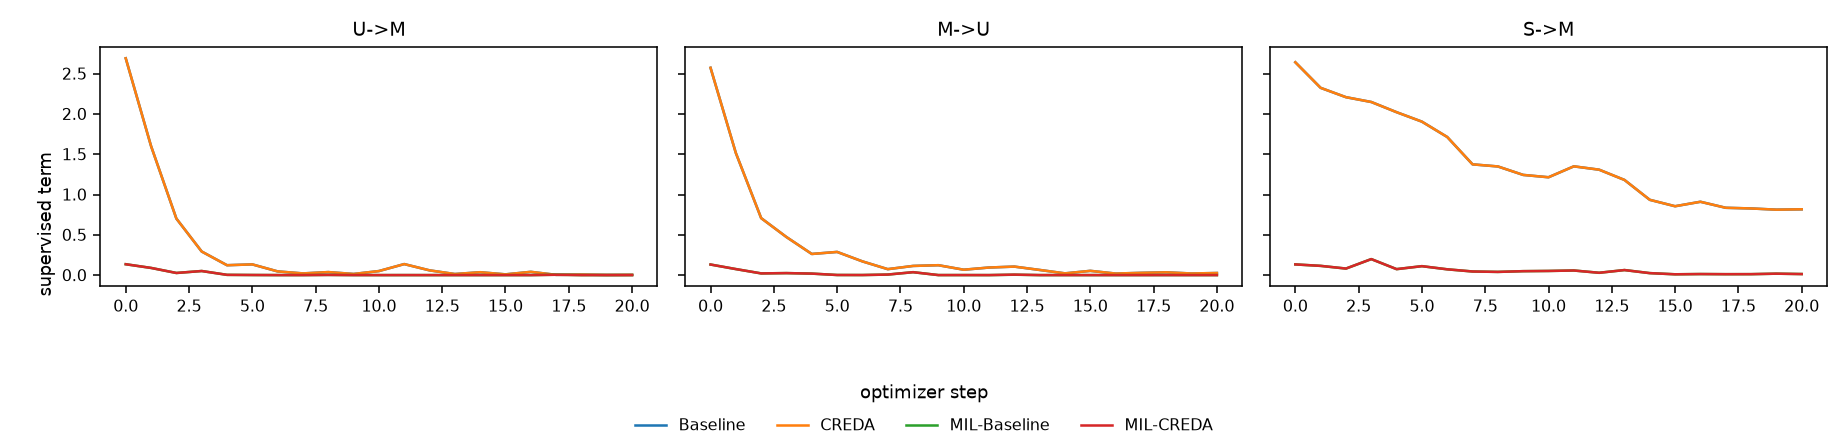

In [57]:
# Se muestra y se guarda en la misma llamada: la copia vectorial queda en Results
# y el cuaderno muestra la imagen, no su nombre de archivo.
display(figures.inline(figures.supervised_curves(
    RESULTS / "curves" / "supervised.pdf",
    runs=RESULTS / "runs.jsonl",
    transfers=FIGURAS)))

#### Las mismas curvas, con el material contaminado (ρ = `NOISE_REPORTED`)

Una curva es un resultado igual que una tabla, y bajo ruido es donde se ve si el término se desestabiliza en vez de simplemente puntuar más bajo. Se muestra acá y se archiva en el árbol de su propia corrida.

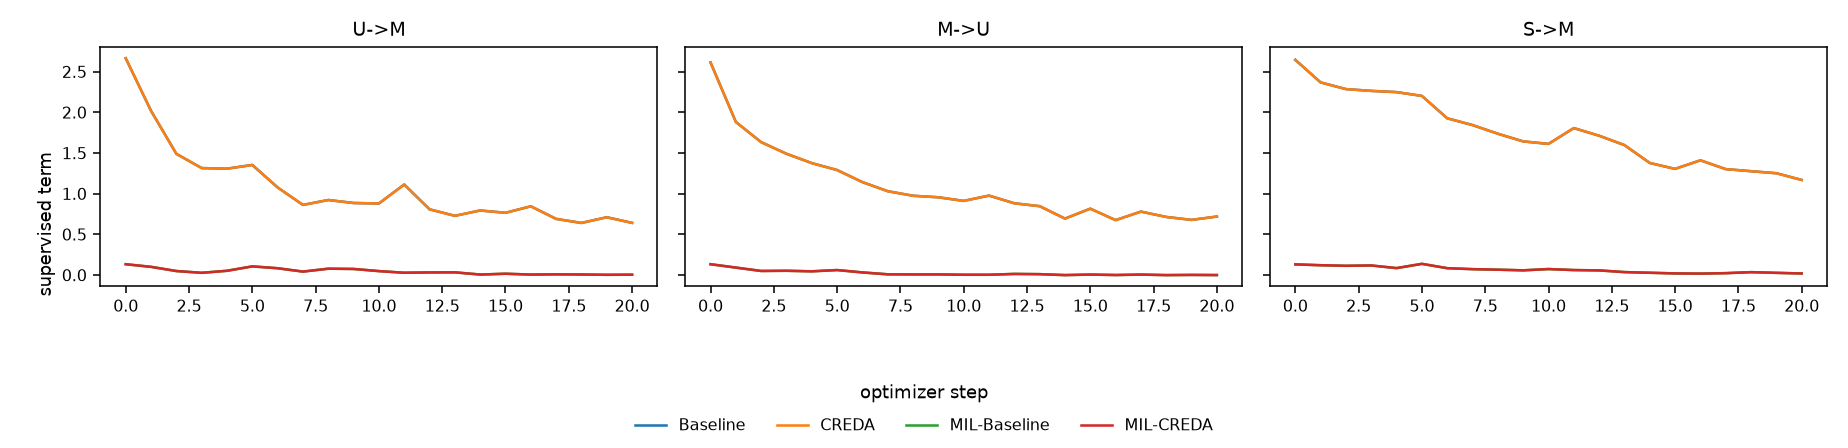

In [58]:
_RUIDO_ROOT = config.results_for(RHO, "campaign", ES_ENSAYO)
if (_RUIDO_ROOT / "runs.jsonl").exists():
    display(figures.inline(figures.supervised_curves(
        _RUIDO_ROOT / "curves" / "supervised.pdf",
        runs=_RUIDO_ROOT / "runs.jsonl",
        transfers=FIGURAS)))
else:
    show(f"La campaña a ρ={RHO:g} no dejó corridas, así que no hay "
         f"segunda figura. No está vacía: no existe.")

## 5 · Las curvas del término de adaptación

Cuánto vale cada término de adaptación a lo largo del entrenamiento. La banda
sombreada es [0, 1]: la §5 normaliza los términos de MIL-CREDA exactamente sobre
ese intervalo y la puntuación del trabajo previo no tiene esa cota, así que si una
curva se queda adentro de la banda —y si ocupa la misma parte de ella de una
transferencia a otra— es la afirmación misma y no una ilustración de ella.
Buscamos curvas dentro de la banda y estables entre pares de dominios.

In [59]:
show(tables.objective("adaptation"))

> **Buscamos que la curva viva dentro de [0, 1] y tienda a cero**, y que ocupe la misma parte del intervalo en las seis transferencias. Salirse de la banda o cambiar de escala entre pares de dominios es el hallazgo.

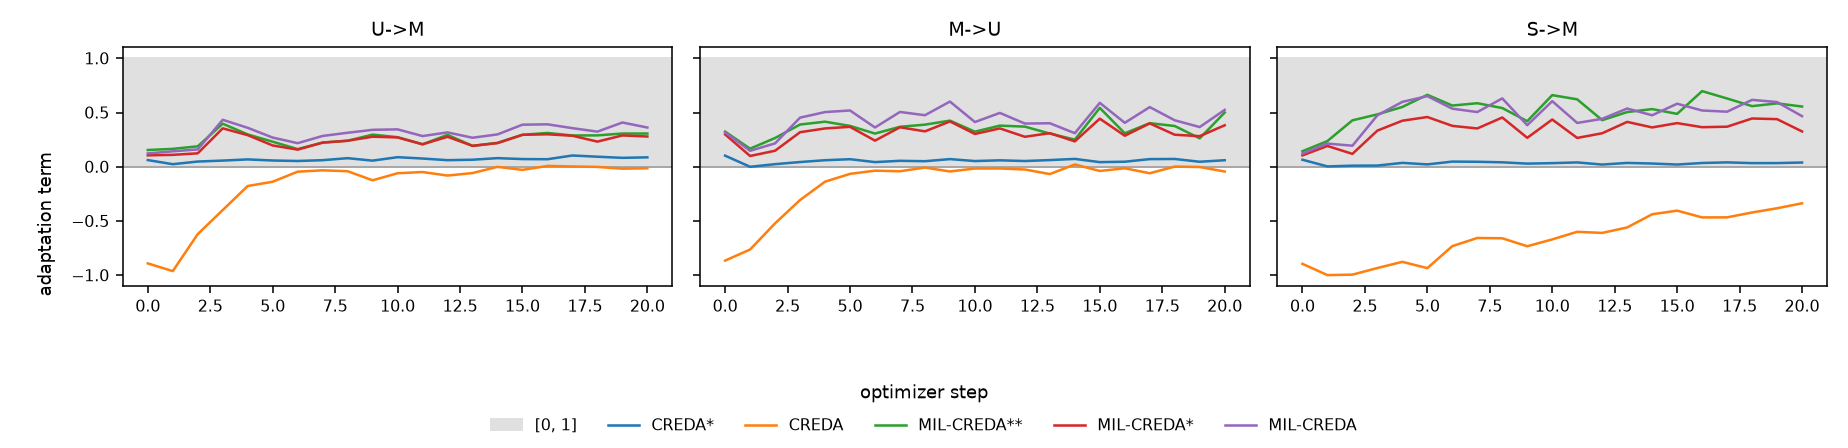

In [60]:
# Se muestra y se guarda en la misma llamada: la copia vectorial queda en Results
# y el cuaderno muestra la imagen, no su nombre de archivo.
display(figures.inline(figures.adaptation_curves(
    RESULTS / "curves" / "adaptation.pdf",
    runs=RESULTS / "runs.jsonl",
    transfers=FIGURAS)))

#### Las mismas curvas, con el material contaminado (ρ = `NOISE_REPORTED`)

Una curva es un resultado igual que una tabla, y bajo ruido es donde se ve si el término se desestabiliza en vez de simplemente puntuar más bajo. Se muestra acá y se archiva en el árbol de su propia corrida.

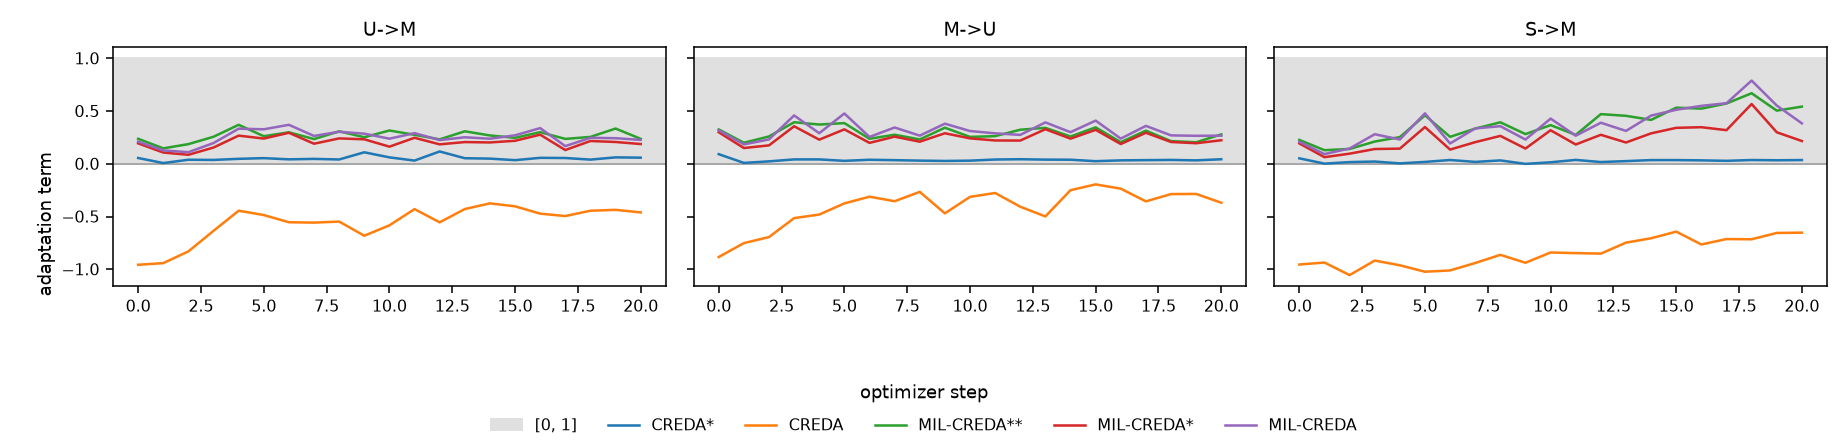

In [61]:
_RUIDO_ROOT = config.results_for(RHO, "campaign", ES_ENSAYO)
if (_RUIDO_ROOT / "runs.jsonl").exists():
    display(figures.inline(figures.adaptation_curves(
        _RUIDO_ROOT / "curves" / "adaptation.pdf",
        runs=_RUIDO_ROOT / "runs.jsonl",
        transfers=FIGURAS)))
else:
    show(f"La campaña a ρ={RHO:g} no dejó corridas, así que no hay "
         f"segunda figura. No está vacía: no existe.")

## 6 · Cuánto del objetivo comanda cada término

Qué proporción del objetivo se lleva de verdad cada término declarado. Sin este
panel, «el término no tuvo efecto» y «el término no tuvo peso» son la misma
figura. El coeficiente está fijo en `RAMP_CEILING` para todos los métodos, y fijar
el coeficiente no fija la proporción: un término cuya magnitud difiere en un orden
entre métodos es una diferencia que nadie declaró, y un peldaño que la ignora le
acredita al mecanismo lo que hizo la escala. Buscamos proporciones comparables
entre métodos, porque es lo que hace legible al peldaño.

In [62]:
show(tables.objective("contribution"))

> **Buscamos que ningún método quede en cero y que los valores sean comparables entre sí.** En cero, «el término no hizo nada» y «el término no pesó nada» son la misma figura; con órdenes distintos entre métodos, el peldaño le acredita al mecanismo lo que hizo la escala.

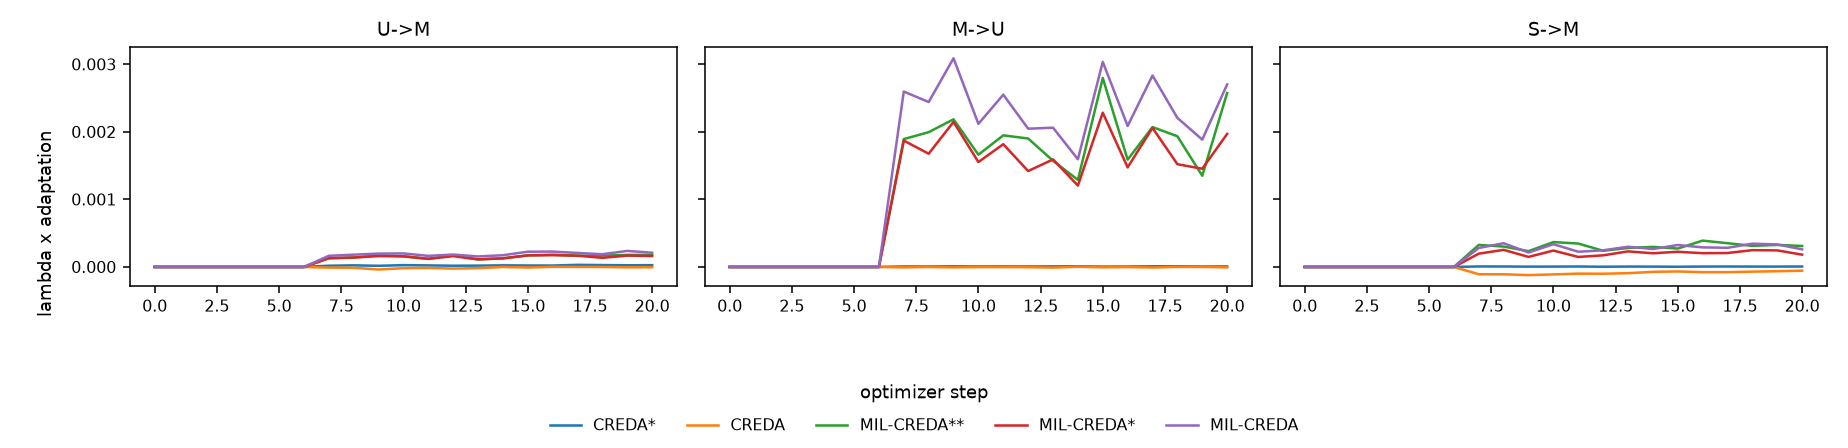

In [63]:
# Se muestra y se guarda en la misma llamada: la copia vectorial queda en Results
# y el cuaderno muestra la imagen, no su nombre de archivo.
display(figures.inline(figures.contribution_curves(
    RESULTS / "curves" / "contribution.pdf",
    runs=RESULTS / "runs.jsonl",
    transfers=FIGURAS)))

#### Las mismas curvas, con el material contaminado (ρ = `NOISE_REPORTED`)

Una curva es un resultado igual que una tabla, y bajo ruido es donde se ve si el término se desestabiliza en vez de simplemente puntuar más bajo. Se muestra acá y se archiva en el árbol de su propia corrida.

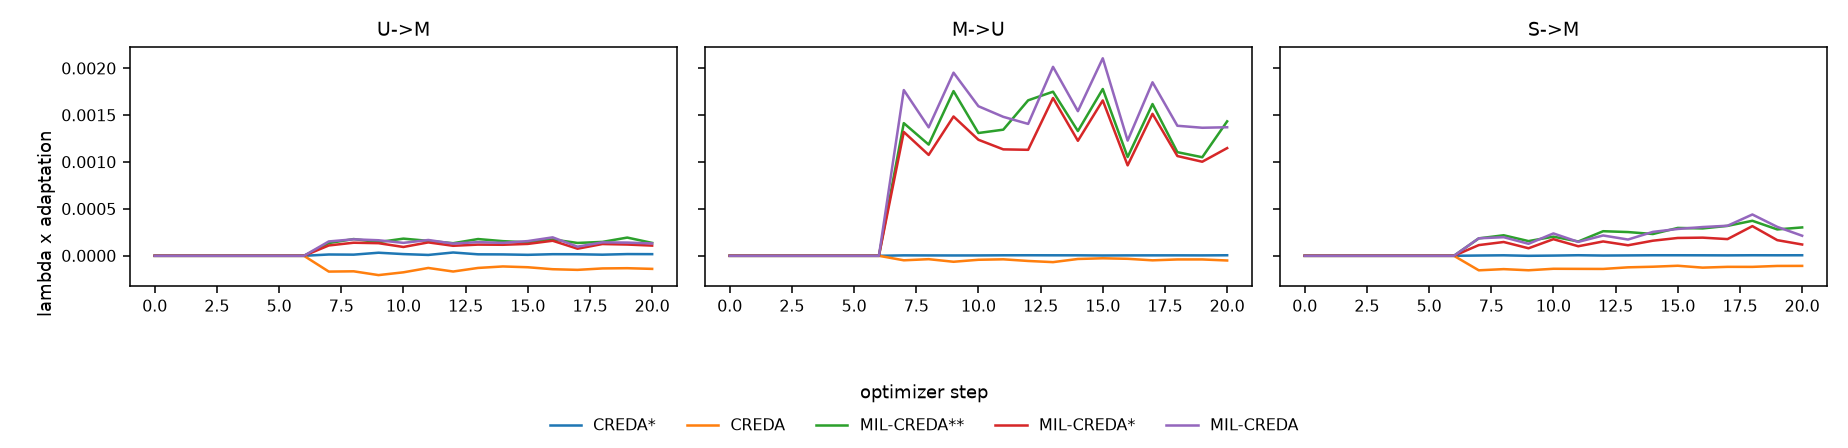

In [64]:
_RUIDO_ROOT = config.results_for(RHO, "campaign", ES_ENSAYO)
if (_RUIDO_ROOT / "runs.jsonl").exists():
    display(figures.inline(figures.contribution_curves(
        _RUIDO_ROOT / "curves" / "contribution.pdf",
        runs=_RUIDO_ROOT / "runs.jsonl",
        transfers=FIGURAS)))
else:
    show(f"La campaña a ρ={RHO:g} no dejó corridas, así que no hay "
         f"segunda figura. No está vacía: no existe.")

## 7 · El registro

Escribe las mismas tablas y conclusiones de arriba en `report.txt` y `report.md`, y
al lado `runs.jsonl` y `summary.json`, que son lo que lee `Benchmark_Latent_v1`. Una sesión
posterior tiene que poder saber que esta corrida ocurrió, bajo qué reducción y contra
qué revisión, y nada de eso vive fuera del repositorio. Se genera junto con los
resultados y nunca se escribe a mano: un resumen escrito a mano es una segunda fuente
de verdad, se desactualiza en silencio y se le cree igual.

In [65]:
# Same as the shown wall-time cell above: `seconds` is `perRun`, so the written report
# carries every run's own reading and never a pooled mean -- `tables.render`
# refuses the dimension outright. `gridPerRun` only exists on a distributed
# campaign's summary; a single-machine run simply has no per-run grid, and
# prints no rows rather than a mean the declaration forbids.
per_run = summary.get("gridPerRun") or {}
seconds_plain = tables.render_per_run(per_run, "seconds")
seconds_md = tables.render_per_run(per_run, "seconds", markdown=True)
seconds_conclusion = tables.conclusion_per_run("seconds")

bloques = [
    harness.header(reduction),
    tables.stamp(summary["reduction"]),
    # La procedencia de los techos, junto a las tablas de techos y no sólo en
    # el cuaderno: el archivo es lo que se cita, así que es el que no puede
    # dejar leer una rejilla de ensayo como una completa.
    PROCEDENCIA_TECHOS,
    tables.render_ceilings(registro_busqueda),
    tables.conclusion_ceilings(registro_busqueda),
    tables.render_ceilings_by_transfer(registro_busqueda, TRANSFERENCIAS),
    tables.conclusion_ceilings_by_transfer(registro_busqueda, TRANSFERENCIAS),
    seconds_plain,
    seconds_conclusion,
    tables.render(runs, "sourceAccuracy", summary["reduction"]),
    tables.conclusion(runs, "sourceAccuracy", summary["reduction"]),
    tables.render_rungs(summary, "sourceAccuracy"),
    tables.conclusion_rungs(summary, "sourceAccuracy"),
    tables.render(runs, "targetAccuracy", summary["reduction"]),
    tables.conclusion(runs, "targetAccuracy", summary["reduction"]),
    tables.render_rungs(summary, "targetAccuracy"),
    tables.conclusion_rungs(summary, "targetAccuracy"),
]
(RESULTS / "report.txt").write_text("\n\n".join(bloques), encoding="utf-8")

(RESULTS / "report.md").write_text("\n\n".join([
    f"# Informe de campaña (v1) — {config.REVISION}",
    tables.stamp(summary["reduction"], markdown=True),
    "## 0 · El techo de cada familia",
    PROCEDENCIA_TECHOS,
    tables.render_ceilings(registro_busqueda, markdown=True),
    tables.conclusion_ceilings(registro_busqueda),
    "### 0b · Qué techo rige en cada transferencia",
    PROCEDENCIA_TECHOS,
    tables.render_ceilings_by_transfer(registro_busqueda, TRANSFERENCIAS, markdown=True),
    tables.conclusion_ceilings_by_transfer(registro_busqueda, TRANSFERENCIAS),
    "## 1 · Tiempo de entrenamiento (más bajo es mejor)",
    seconds_md,
    seconds_conclusion,
    "## 2 · Exactitud en fuente (más alto es mejor)",
    tables.render(runs, "sourceAccuracy", summary["reduction"], markdown=True),
    tables.conclusion(runs, "sourceAccuracy", summary["reduction"]),
    "### 2b · Peldaños en fuente",
    tables.render_rungs(summary, "sourceAccuracy", markdown=True),
    tables.conclusion_rungs(summary, "sourceAccuracy"),
    "## 3 · Exactitud en destino (más alto es mejor)",
    tables.render(runs, "targetAccuracy", summary["reduction"], markdown=True),
    tables.conclusion(runs, "targetAccuracy", summary["reduction"]),
    "### 3b · Peldaños en destino",
    tables.render_rungs(summary, "targetAccuracy", markdown=True),
    tables.conclusion_rungs(summary, "targetAccuracy"),
]), encoding="utf-8")

print("escritos:")
for path in sorted(RESULTS.iterdir()):
    print(" ", path.relative_to(config.REPOSITORY))

escritos:
  MIL-CREDA/Results/Pilot/Benchmark/curves
  MIL-CREDA/Results/Pilot/Benchmark/latent
  MIL-CREDA/Results/Pilot/Benchmark/latent.json
  MIL-CREDA/Results/Pilot/Benchmark/latent.md
  MIL-CREDA/Results/Pilot/Benchmark/report.md
  MIL-CREDA/Results/Pilot/Benchmark/report.txt
  MIL-CREDA/Results/Pilot/Benchmark/runs.jsonl
  MIL-CREDA/Results/Pilot/Benchmark/shard.json
  MIL-CREDA/Results/Pilot/Benchmark/summary.json


In [66]:
# El sello: contra qué código corrió este informe. Sin él, un informe viejo y uno
# recién generado se ven idénticos y el viejo se sigue creyendo.
from MIL_CREDA_Benchmark import report_digest

print(report_digest.stamp())

SOURCES-SHA256 9b86a90c580a1686ae3f030217dd2215eade4841abb8a790430f003920384e8d
